In [1]:
import pandas as pd         
import numpy as np                
import matplotlib.pyplot as plt                       
import seaborn as sns           

In [2]:
df = pd.read_csv("penguins.csv")

In [3]:
df.head(4)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN


In [4]:
df["island"].unique().tolist()

['Torgersen', 'Biscoe', 'Dream']

In [5]:
df["species"].unique().tolist()

['Adelie', 'Chinstrap', 'Gentoo']

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 24.9 KB


In [7]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=3)
num_cols = df.select_dtypes(include=["number"]).columns
df[num_cols] = imputer.fit_transform(df[num_cols])

In [8]:
df.isna().sum()

species               0
island                0
bill_length_mm        0
bill_depth_mm         0
flipper_length_mm     0
body_mass_g           0
sex                  11
dtype: int64

In [9]:
df.drop(columns=["sex"])

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,Adelie,Torgersen,39.10000,18.70000,181.000000,3750.000000
1,Adelie,Torgersen,39.50000,17.40000,186.000000,3800.000000
2,Adelie,Torgersen,40.30000,18.00000,195.000000,3250.000000
3,Adelie,Torgersen,43.92193,17.15117,200.915205,4201.754386
4,Adelie,Torgersen,36.70000,19.30000,193.000000,3450.000000
...,...,...,...,...,...,...
339,Gentoo,Biscoe,43.92193,17.15117,200.915205,4201.754386
340,Gentoo,Biscoe,46.80000,14.30000,215.000000,4850.000000
341,Gentoo,Biscoe,50.40000,15.70000,222.000000,5750.000000
342,Gentoo,Biscoe,45.20000,14.80000,212.000000,5200.000000


In [10]:
df_num =df.select_dtypes(include="number")

In [11]:
df_num.columns.tolist()

['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

In [12]:
for species in df["species"].unique():
    print(df[df["species"] == species])

    species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0    Adelie  Torgersen        39.10000       18.70000         181.000000   
1    Adelie  Torgersen        39.50000       17.40000         186.000000   
2    Adelie  Torgersen        40.30000       18.00000         195.000000   
3    Adelie  Torgersen        43.92193       17.15117         200.915205   
4    Adelie  Torgersen        36.70000       19.30000         193.000000   
..      ...        ...             ...            ...                ...   
147  Adelie      Dream        36.60000       18.40000         184.000000   
148  Adelie      Dream        36.00000       17.80000         195.000000   
149  Adelie      Dream        37.80000       18.10000         193.000000   
150  Adelie      Dream        36.00000       17.10000         187.000000   
151  Adelie      Dream        41.50000       18.50000         201.000000   

     body_mass_g     sex  
0    3750.000000    MALE  
1    3800.000000  FEMALE  
2    3

In [13]:
mycols = df_num.columns
selected_col = mycols[0]

print(selected_col)

bill_length_mm


In [14]:
df.columns.tolist()

['species',
 'island',
 'bill_length_mm',
 'bill_depth_mm',
 'flipper_length_mm',
 'body_mass_g',
 'sex']

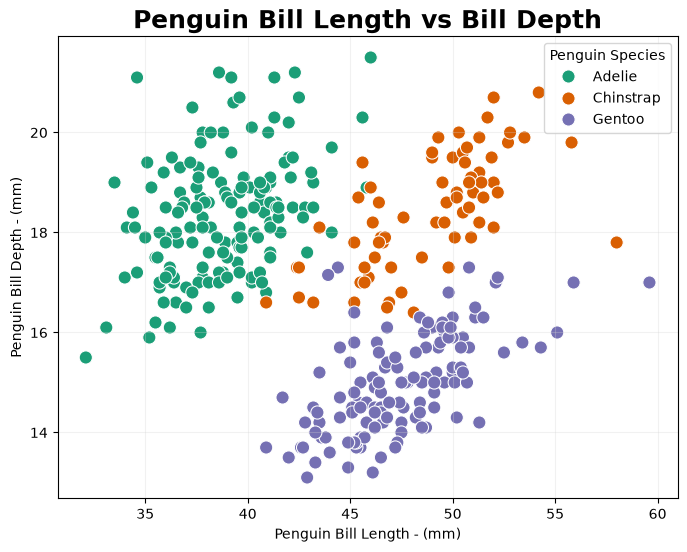

In [15]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df,
                x="bill_length_mm",
                y="bill_depth_mm",
                hue="species",
                palette="Dark2",
                s=90
                )
plt.xlabel("Penguin Bill Length - (mm)")
plt.legend(title="Penguin Species")
plt.ylabel("Penguin Bill Depth - (mm)")
plt.grid(color="lightgray", alpha=0.3)
plt.title("Penguin Bill Length vs Bill Depth", fontweight="bold", fontsize=18)
plt.show()

In [20]:
spec = df["species"].unique().tolist()

In [21]:
penguin_dict = {
    species: df[df["species"] == species]
    for species in df["species"].unique()
}

In [25]:
for row in penguin_dict["Adelie"].iterrows():
    print(row)

(0, species                 Adelie
island               Torgersen
bill_length_mm            39.1
bill_depth_mm             18.7
flipper_length_mm        181.0
body_mass_g             3750.0
sex                       MALE
Name: 0, dtype: object)
(1, species                 Adelie
island               Torgersen
bill_length_mm            39.5
bill_depth_mm             17.4
flipper_length_mm        186.0
body_mass_g             3800.0
sex                     FEMALE
Name: 1, dtype: object)
(2, species                 Adelie
island               Torgersen
bill_length_mm            40.3
bill_depth_mm             18.0
flipper_length_mm        195.0
body_mass_g             3250.0
sex                     FEMALE
Name: 2, dtype: object)
(3, species                   Adelie
island                 Torgersen
bill_length_mm          43.92193
bill_depth_mm           17.15117
flipper_length_mm     200.915205
body_mass_g          4201.754386
sex                          NaN
Name: 3, dtype: object)
(4, sp

In [26]:
df["bill_depth_mm"].values

array([18.7       , 17.4       , 18.        , 17.15116959, 19.3       ,
       20.6       , 17.8       , 19.6       , 18.1       , 20.2       ,
       17.1       , 17.3       , 17.6       , 21.2       , 21.1       ,
       17.8       , 19.        , 20.7       , 18.4       , 21.5       ,
       18.3       , 18.7       , 19.2       , 18.1       , 17.2       ,
       18.9       , 18.6       , 17.9       , 18.6       , 18.9       ,
       16.7       , 18.1       , 17.8       , 18.9       , 17.        ,
       21.1       , 20.        , 18.5       , 19.3       , 19.1       ,
       18.        , 18.4       , 18.5       , 19.7       , 16.9       ,
       18.8       , 19.        , 18.9       , 17.9       , 21.2       ,
       17.7       , 18.9       , 17.9       , 19.5       , 18.1       ,
       18.6       , 17.5       , 18.8       , 16.6       , 19.1       ,
       16.9       , 21.1       , 17.        , 18.2       , 17.1       ,
       18.        , 16.2       , 19.1       , 16.6       , 19.4 

In [28]:
df["lable"] = np.where(df["bill_depth_mm"]>20,  "big", "small")

In [29]:
df_num

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.10000,18.70000,181.000000,3750.000000
1,39.50000,17.40000,186.000000,3800.000000
2,40.30000,18.00000,195.000000,3250.000000
3,43.92193,17.15117,200.915205,4201.754386
4,36.70000,19.30000,193.000000,3450.000000
...,...,...,...,...
339,43.92193,17.15117,200.915205,4201.754386
340,46.80000,14.30000,215.000000,4850.000000
341,50.40000,15.70000,222.000000,5750.000000
342,45.20000,14.80000,212.000000,5200.000000


In [30]:
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipe = Pipeline([("scale", StandardScaler()),
                 ("pca",PCA(n_components=2))])

model = pipe.fit_transform(df_num)

In [33]:
df_pca = pd.DataFrame(model, columns=["PC1", "PC2"])
df_pca["species"] = df["species"].values

In [34]:
df_pca

,PC1,PC2,species
0,-1.848827e+00,4.784149e-02,Adelie
1,-1.310577e+00,-4.295989e-01,Adelie
2,-1.373179e+00,-1.549274e-01,Adelie
3,-1.732416e-16,1.020506e-15,Adelie
4,-1.884312e+00,-2.054387e-03,Adelie
...,...,...,...
339,-1.732416e-16,1.020506e-15,Gentoo
340,1.846261e+00,-7.699555e-01,Gentoo
341,2.768803e+00,2.897299e-01,Gentoo
342,1.727393e+00,-7.063257e-01,Gentoo


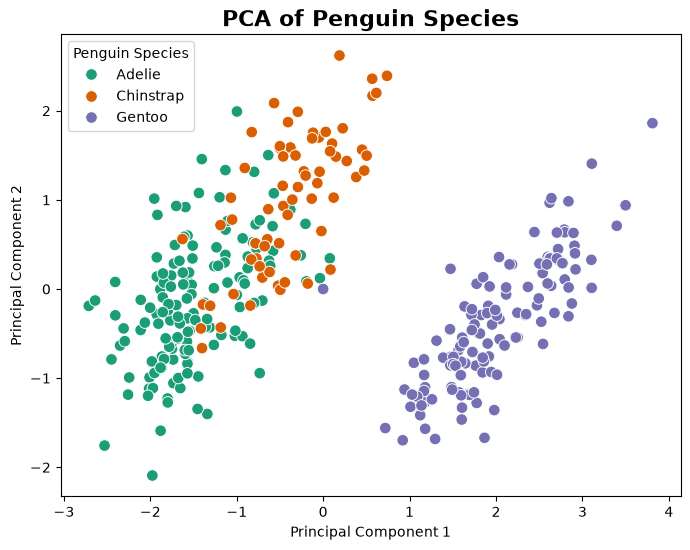

In [43]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_pca,
                x="PC1",
                y="PC2",
                hue="species",
                s=70,
                palette="Dark2")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Penguin Species")
plt.title("PCA of Penguin Species", fontweight="bold", fontsize=16)
plt.show()